# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


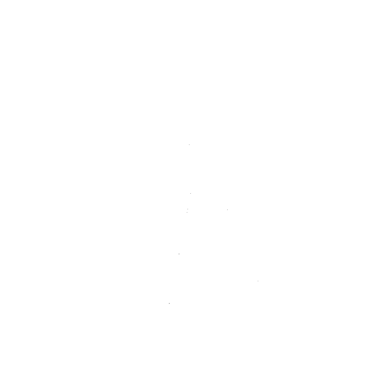

Threshold value: 50


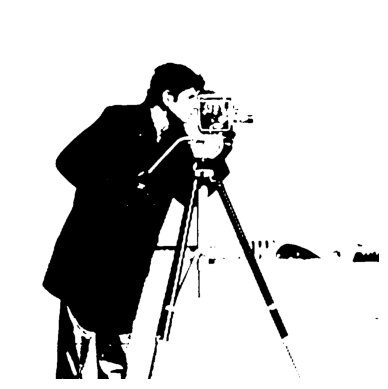

Threshold value: 100


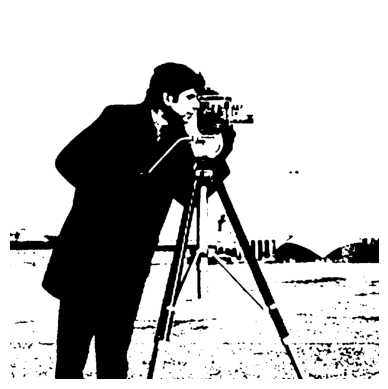

Threshold value: 150


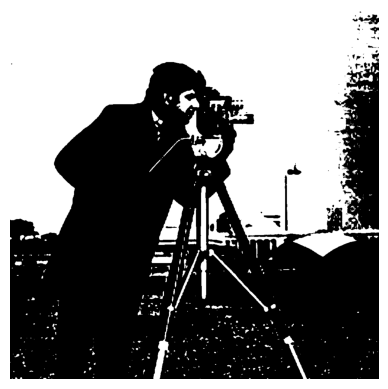

Threshold value: 200


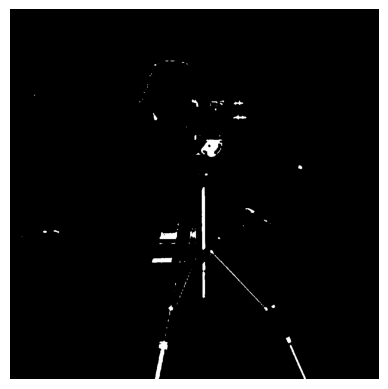

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    
    ret_thresh_value, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )
    
    print(f"Threshold value: {threshold_value}")
    
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image: 


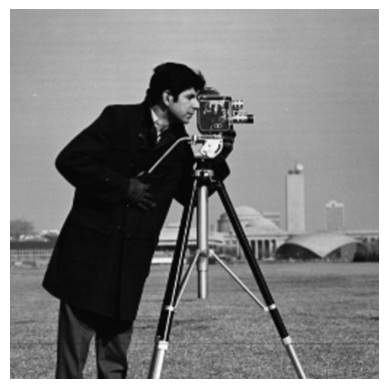

In [4]:
print("Original Image: ")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

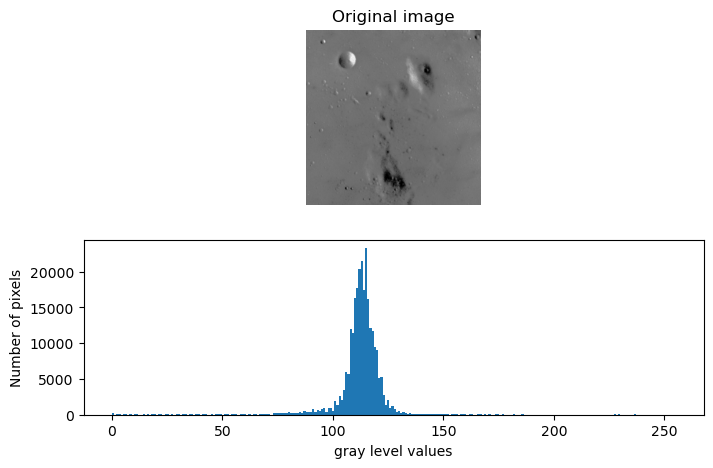

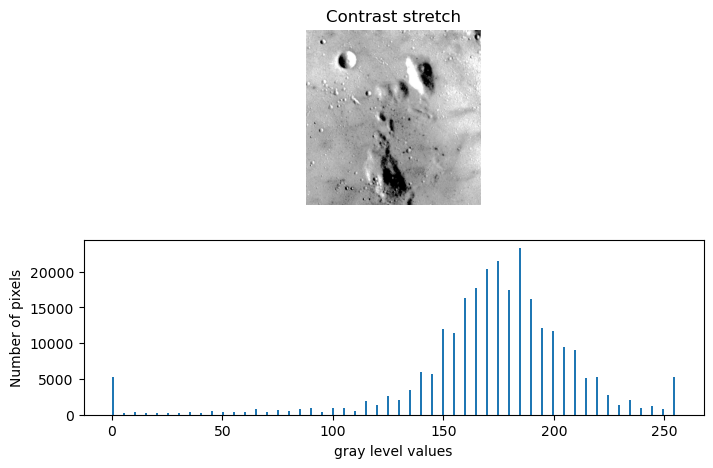

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


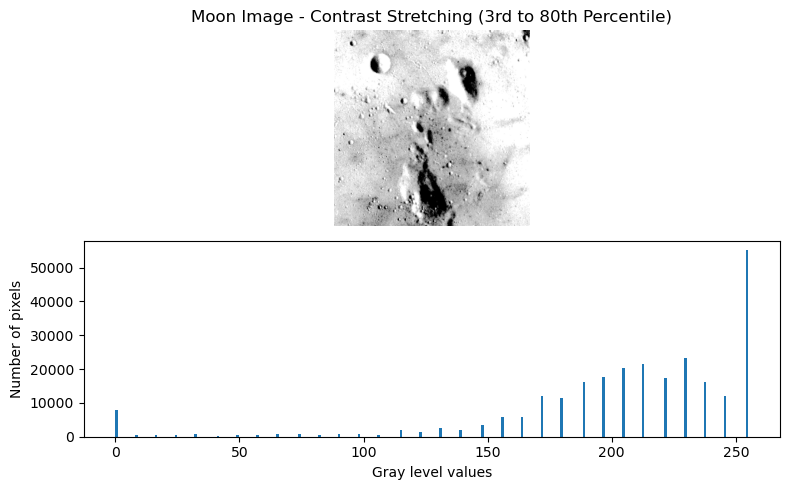

In [6]:
# Task 1:
# Rescale the moon image using the 3rd and 80th percentiles

img = data.moon()

# Find the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale intensity
img_rescale_3_80 = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

# Display the rescaled image and its histogram
fig = plt.figure(figsize=(8, 5))

fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Moon Image - Contrast Stretching (3rd to 80th Percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()

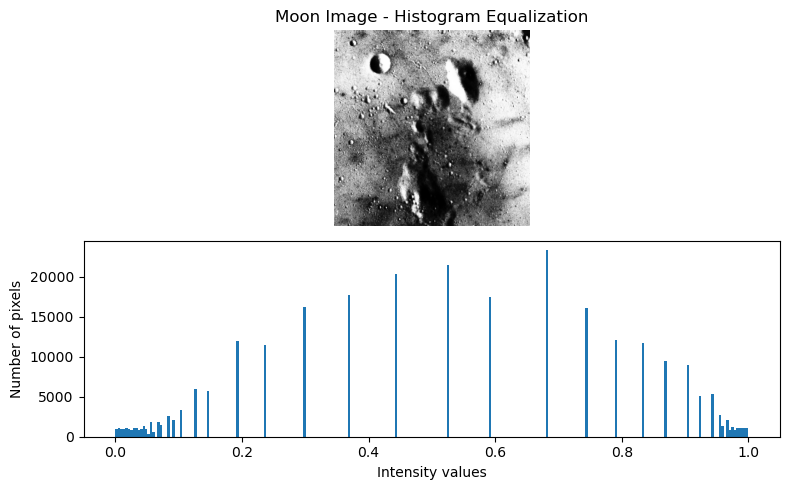

In [7]:
# Task 2:
# Apply histogram equalization to the moon image

img = data.moon()

# Histogram equalization
img_equalized = exposure.equalize_hist(img)

# Display the equalized image and its histogram
fig = plt.figure(figsize=(8, 5))

fig.add_subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Moon Image - Histogram Equalization')

fig.add_subplot(2, 1, 2)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('Intensity values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()

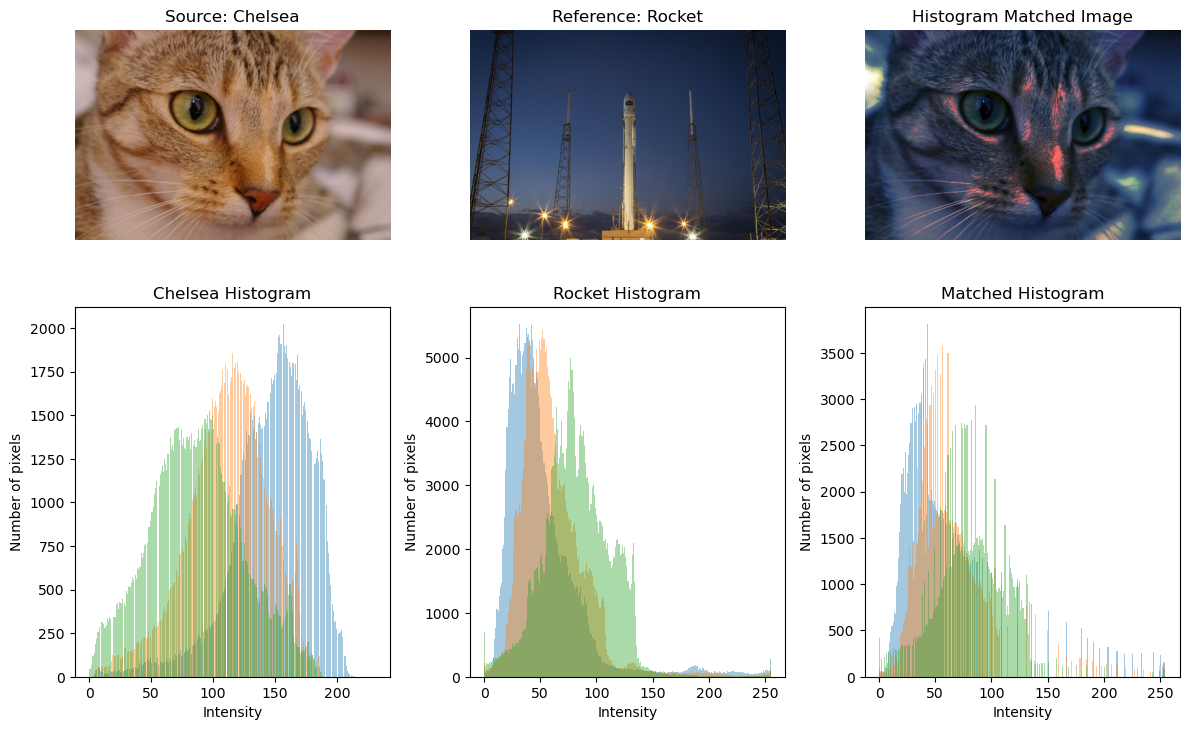

In [8]:
# Task 3:
# Use rocket as the reference image
# Match the histogram of chelsea to rocket

reference = data.rocket()
source = data.chelsea()

# Match the histogram
matched = exposure.match_histograms(
    source,
    reference,
    channel_axis=-1
)

# Display the images
fig = plt.figure(figsize=(12, 8))

fig.add_subplot(2, 3, 1)
plt.imshow(source)
plt.axis('off')
plt.title('Source: Chelsea')

fig.add_subplot(2, 3, 2)
plt.imshow(reference)
plt.axis('off')
plt.title('Reference: Rocket')

fig.add_subplot(2, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched Image')

# Chelsea histogram
for channel in range(3):
    plt.subplot(2, 3, 4)
    plt.hist(source[..., channel].ravel(), bins=256, alpha=0.4)

plt.title('Chelsea Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

# Rocket histogram
for channel in range(3):
    plt.subplot(2, 3, 5)
    plt.hist(reference[..., channel].ravel(), bins=256, alpha=0.4)

plt.title('Rocket Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

# Matched image histogram
for channel in range(3):
    plt.subplot(2, 3, 6)
    plt.hist(matched[..., channel].ravel(), bins=256, alpha=0.4)

plt.title('Matched Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()